# X-ray diseases classifier

This notebook demonstrates an image classification approach for analyzing chest X-ray images. The project uses the NIH Chest X-ray dataset and focuses on exploring a proof-of-concept method for detecting thoracic findings from medical imaging data.

Rabi Arbi, 2026

![banner](https://d1qpnt4t1p05jk.cloudfront.net/wp-content/uploads/2025/10/27082644/image-2544-1024x683.jpeg)

In [1]:
import collections, lightning, pandas as pd, platform, os, torch, torchvision, warnings

from torch.utils.data import Dataset, DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
from torchvision import transforms
from torchmetrics.classification import MultilabelAccuracy, MultilabelPrecision, MultilabelRecall
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

import matplotlib.pyplot as plt

lightning.seed_everything(42)
torch.set_float32_matmul_precision("high")

data_path = "data"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

trainer_kwargs = {
    "accelerator": "gpu" if use_cuda else "cpu",
    "devices": 1,
}

if use_cuda:
    trainer_kwargs["precision"] = "16-mixed"

print(
    "Versions: python", platform.python_version(),
    "| torch", torch.__version__,
    "| torchvision", torchvision.__version__,
    "| lightning", lightning.__version__,
)
print("CUDA available:", use_cuda)
print("Active device:", device)
print("GPU:", torch.cuda.get_device_name(0) if use_cuda else "N/A")
print("Trainer kwargs:", trainer_kwargs)

W0407 19:59:54.282000 9076 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


Versions: python 3.14.0 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | lightning 2.6.1
CUDA available: True
Active device: cuda
GPU: NVIDIA GeForce RTX 5080
Trainer kwargs: {'accelerator': 'gpu', 'devices': 1, 'precision': '16-mixed'}


### explanation

- `collections` → counts labels and checks class balance  
- `lightning` → organizes training structure  
- `pandas` → reads and processes the dataset CSV  
- `platform` → shows Python/version info  
- `os` → handles file paths  
- `torch` → core deep learning library  
- `torchvision` → image utilities and transforms  
- `warnings` → controls warning messages  

- `Dataset` → builds a custom NIH dataset class  
- `DataLoader` → loads images in batches  

- `LightningDataModule` → manages data loading and splits  
- `LightningModule` → defines model, loss, and training steps  
- `Trainer` → runs training and validation  

- `transforms` → preprocesses X-ray images  
- `MultilabelAccuracy` → evaluates multi-label predictions  
- `MultilabelPrecision` → checks how many positive predictions are correct  
- `MultilabelRecall` → checks how many real positives are found  

- `CSVLogger` → saves training results  
- `EarlyStopping` → stops training when improvement stalls  
- `matplotlib.pyplot` → plots images and training curves  

- `seed_everything(42)` → makes runs reproducible  
- `set_float32_matmul_precision("high")` → improves GPU computation performance  
- `data_path = "data"` → sets dataset folder  
- `print(...)` → shows library versions

------------------------------------------------------------------------------------

# Loading a pre-trained model

In [2]:
import torch.nn as nn
import torchvision

num_classes = 14

pretrained_model = torchvision.models.resnet50(weights="DEFAULT")
pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, num_classes)

criterion = nn.BCEWithLogitsLoss()

## What each part does:

- `resnet50(weights="DEFAULT")` → loads pretrained ResNet50
- `nn.Linear(...)` → replaces the last layer
- `num_classes` = 14 → one output per chest finding
- `BCEWithLogitsLoss()` → correct loss for multi-label prediction

### Why the last layer was replaced

The old last layer was built for a different task.

This pretrained `ResNet50` came from ImageNet, so its final layer was made to predict **1000 ImageNet classes** such as dogs, cars, chairs, and other everyday objects.

This project is different:
- **input** = chest X-ray image  
- **output** = 14 thoracic findings  

So the original last layer does not match this target.

Inside the model:
- the early and middle layers learn general visual features  
- the last layer maps those features to the final class outputs  

That last mapping is task-specific.

The last layer was replaced because:
- the ImageNet output size is wrong  
- this project needs **14 outputs**  
- the new classes are completely different  
- this is how transfer learning adapts a pretrained model to a new task  

Simple example:

**Before**
- model sees an image  
- final layer predicts one of **1000 ImageNet classes**  

**After**
- model sees a chest X-ray  
- final layer predicts the 14 chest findings, such as **Atelectasis, Effusion, Mass, Pneumonia**, and others.

------------------------------------------------------------------------------------------------------

## Clean The Data


### No Finding Analysis

We will measure how many images are labeled **No Finding**. These samples may add less value for disease classification, so we review their proportion before deciding whether to keep or remove them.

CSV used: Data_Entry_2017.csv
Total images: 112120
Images with No Finding: 60361
No Finding ratio: 53.84%


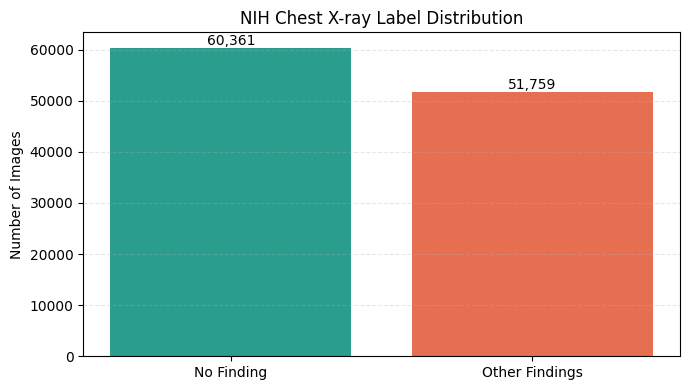

In [3]:
from pathlib import Path

# Locate NIH metadata CSV from common project layouts.
candidate_csv_paths = [
    Path(data_path) / "Data_Entry_2017.csv",
    Path("Data_Entry_2017.csv"),
    Path("archive") / "Data_Entry_2017.csv",
]

csv_path = next((p for p in candidate_csv_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find Data_Entry_2017.csv. Checked: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

df = pd.read_csv(csv_path)

if "Finding Labels" not in df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the metadata CSV.")

no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
no_finding_count = int(no_finding_mask.sum())
total_images = len(df)
other_findings_count = total_images - no_finding_count

print(f"CSV used: {csv_path}")
print(f"Total images: {total_images}")
print(f"Images with No Finding: {no_finding_count}")
print(f"No Finding ratio: {no_finding_count / total_images:.2%}")

# Quick class-balance chart.
labels = ["No Finding", "Other Findings"]
counts = [no_finding_count, other_findings_count]
colors = ["#2a9d8f", "#e76f51"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts, color=colors)
plt.title("NIH Chest X-ray Label Distribution")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Why It Can Be Better to Remove Some No Finding Images:
In this task, removing a portion of **No Finding** images can improve learning because the model then sees more disease-positive examples, reducing class imbalance and helping it focus on patterns related to thoracic abnormalities.

In [4]:
# Prints only the number of images after removal (skip if removal not run yet).
if "total_after" in globals():
    print(total_after)
elif "df_clean" in globals():
    total_after = len(df_clean)
    print(total_after)
else:
    print("No Finding removal has not run yet. Skipping count.")

No Finding removal has not run yet. Skipping count.


Total images before: 112120
No Finding images removed: 60361
Total images after removal: 51759


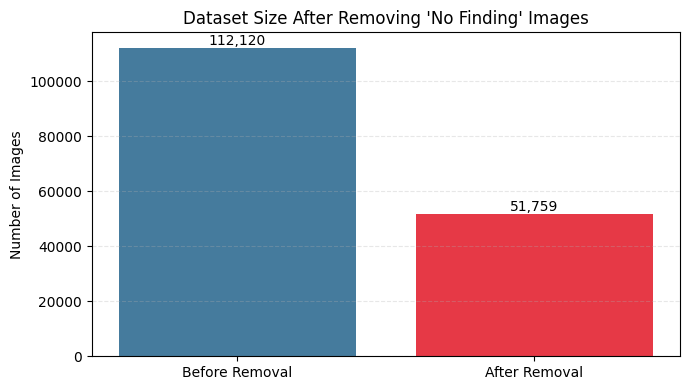

In [5]:
# Remove all rows labeled 'No Finding'. Skip if already removed.
if "df_clean" in globals() and "total_after" in globals():
    print("No Finding rows already removed. Skipping.")
else:
    if "df" not in globals():
        raise NameError("Run the metadata loading cell first to create df.")

    if "Finding Labels" not in df.columns:
        raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

    no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
    df_clean = df.loc[~no_finding_mask].copy()

    total_before = len(df)
    total_after = len(df_clean)
    removed_count = total_before - total_after

    print(f"Total images before: {total_before}")
    print(f"No Finding images removed: {removed_count}")
    print(f"Total images after removal: {total_after}")

    # Final chart: dataset size before vs after removing No Finding rows.
    labels = ["Before Removal", "After Removal"]
    counts = [total_before, total_after]
    colors = ["#457b9d", "#e63946"]

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, counts, color=colors)
    plt.title("Dataset Size After Removing 'No Finding' Images")
    plt.ylabel("Number of Images")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

Also some images in the dataset contain multiple disease labels, which can confuse the model because it is unclear which disease is the correct target. To improve model clarity and performance, these images will be removed. Only images with a single, clear disease label will be used, ensuring that each input corresponds to one specific prediction.


In [6]:
# Count images that have more than one disease label (excluding 'No Finding').
if "Finding Labels" not in df_clean.columns:
    raise KeyError("Column 'Finding Labels' was not found in df_clean.")

label_count = (
    df_clean["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

multi_disease_count = int((label_count > 1).sum())
print(multi_disease_count)

20796


# Keep only one single-label image per patient and drop the rest.


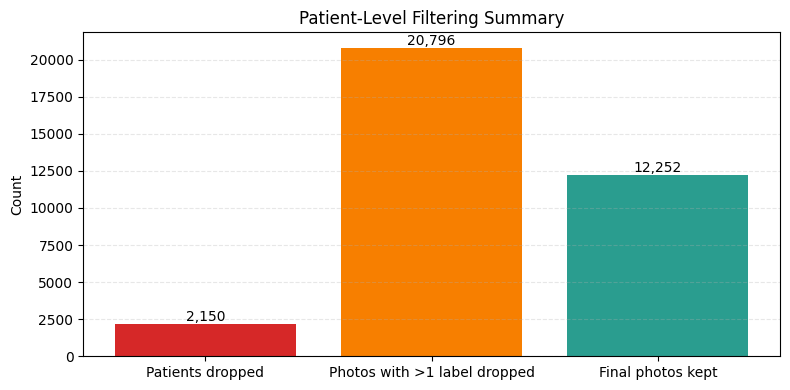

Patients dropped: 2150
Photos with >1 label dropped: 20796
Final photos kept (1 per patient): 12252


In [7]:
base_df = df_clean.copy() if "df_clean" in globals() else df.copy()

if "Finding Labels" not in base_df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in base_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column was not found in the dataframe.")

label_count_base = (
    base_df["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

single_label_df = base_df.loc[label_count_base == 1].copy()

if "Image Index" in single_label_df.columns:
    single_label_df = single_label_df.sort_values([patient_col, "Image Index"])
else:
    single_label_df = single_label_df.sort_values([patient_col])

df_one_image_per_patient = single_label_df.drop_duplicates(subset=patient_col, keep="first").copy()

patients_before = int(base_df[patient_col].nunique())
patients_after = int(df_one_image_per_patient[patient_col].nunique())
patients_dropped = patients_before - patients_after

multi_label_photos_dropped = int((label_count_base > 1).sum())
final_photos_kept = int(len(df_one_image_per_patient))

labels = ["Patients dropped", "Photos with >1 label dropped", "Final photos kept"]
values = [patients_dropped, multi_label_photos_dropped, final_photos_kept]
colors = ["#d62828", "#f77f00", "#2a9d8f"]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Patient-Level Filtering Summary")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Patients dropped: {patients_dropped}")
print(f"Photos with >1 label dropped: {multi_label_photos_dropped}")
print(f"Final photos kept (1 per patient): {final_photos_kept}")

# Chart: total images before any cleaning vs final images after all cleaning.


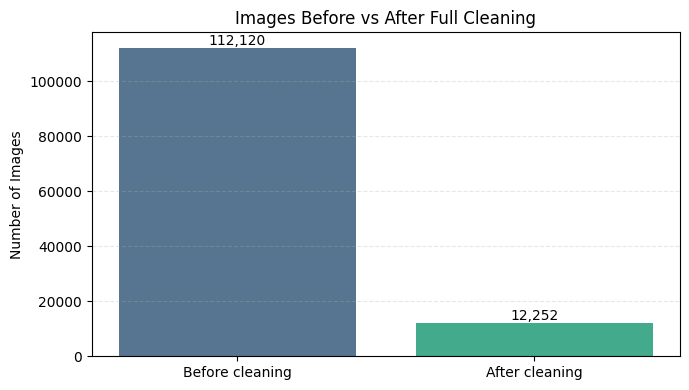

Before cleaning: 112120
After cleaning: 12252


In [8]:
before_cleaning = len(df) if "df" in globals() else total_images
after_cleaning = len(df_one_image_per_patient) if "df_one_image_per_patient" in globals() else final_photos_kept

labels = ["Before cleaning", "After cleaning"]
values = [before_cleaning, after_cleaning]
colors = ["#577590", "#43aa8b"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Images Before vs After Full Cleaning")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Before cleaning: {before_cleaning}")
print(f"After cleaning: {after_cleaning}")

# Randomly show 10 patients with one image ID and its label.


In [9]:
sample_df = df_one_image_per_patient.copy()

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in sample_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column not found.")

image_col_candidates = ["Image Index", "ImageID", "image_id"]
image_col = next((c for c in image_col_candidates if c in sample_df.columns), None)
if image_col is None:
    raise KeyError("Image ID column not found.")

if "Finding Labels" not in sample_df.columns:
    raise KeyError("'Finding Labels' column not found.")

total_images_kept = len(sample_df)
n = min(10, total_images_kept)
random_10 = sample_df.sample(n=n).loc[:, [patient_col, image_col, "Finding Labels"]]
random_10 = random_10.reset_index(drop=True)

print(f"Total images after all filtering: {total_images_kept}")
print(f"Random sample of {n} patients (new each run):")
display(random_10)

Total images after all filtering: 12252
Random sample of 10 patients (new each run):


,Patient ID,Image Index,Finding Labels
0,22963,00022963_000.png,Infiltration
1,957,00000957_001.png,Atelectasis
2,7354,00007354_007.png,Infiltration
3,18190,00018190_000.png,Infiltration
4,18156,00018156_001.png,Atelectasis
5,22484,00022484_006.png,Consolidation
6,7166,00007166_001.png,Emphysema
7,11244,00011244_000.png,Atelectasis
8,3376,00003376_000.png,Effusion
9,2996,00002996_000.png,Pleural_Thickening


## Number of images Per class

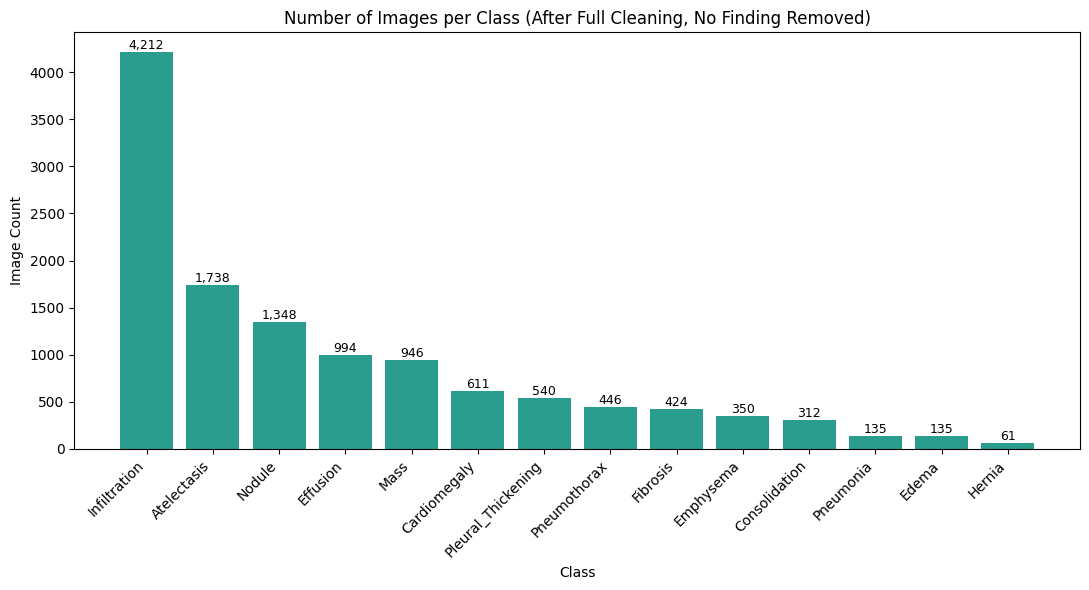

Total rows used for plotting: 12,252
Total disease labels plotted: 12,252
Total unique classes: 14


In [10]:
# Number of images per class after full cleaning (excluding 'No Finding')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def build_clean_df(base_df: pd.DataFrame) -> pd.DataFrame:
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column was not found in the dataframe.")

    disease_df = base_df.loc[
        ~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")
    ].copy()
    label_count = disease_df["Finding Labels"].fillna("").astype(str).str.split("|").str.len()
    single_label_df = disease_df.loc[label_count == 1].copy()

    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in single_label_df.columns else [])
    return single_label_df.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first")

if "df_one_image_per_patient" in globals():
    plot_df = df_one_image_per_patient.copy()
else:
    if "df" in globals():
        base_df = df.copy()
    else:
        csv_candidates = [
            Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
            Path("Data_Entry_2017.csv"),
            Path("archive") / "Data_Entry_2017.csv",
        ]
        csv_path = next((p for p in csv_candidates if p.exists()), None)
        if csv_path is None:
            raise FileNotFoundError("Could not find Data_Entry_2017.csv")
        base_df = pd.read_csv(csv_path)

    if "Finding Labels" not in base_df.columns:
        raise KeyError("Column 'Finding Labels' not found in the dataframe.")
    plot_df = build_clean_df(base_df)

class_counts = (
    plot_df["Finding Labels"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne("") & s.str.casefold().ne("no finding")]
    .value_counts()
    .sort_values(ascending=False)
 )

if class_counts.empty:
    raise ValueError("No disease labels found after cleaning.")

plt.figure(figsize=(11, 6))
bars = plt.bar(class_counts.index, class_counts.values, color="#2a9d8f")
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)

plt.title("Number of Images per Class (After Full Cleaning, No Finding Removed)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Total rows used for plotting: {len(plot_df):,}")
print(f"Total disease labels plotted: {int(class_counts.sum()):,}")
print(f"Total unique classes: {class_counts.size}")

# Resize the images
 the images sizes are Too big (1024 * 1024) it will get too heavy to train the model the best solution is to resize it down to 512 * 512

In [ ]:
from pathlib import Path
from PIL import Image

# Choose which image list to resize: filtered training set if available, otherwise all metadata rows.
resize_df = df_one_image_per_patient if "df_one_image_per_patient" in globals() else df

if "Image Index" not in resize_df.columns:
    raise KeyError("Column 'Image Index' not found in the dataframe.")

target_size = (512, 512)

# Support running notebook either from project root or from archive/ folder.
base_candidates = [Path("."), Path("archive")]
image_roots = []
for base in base_candidates:
    image_roots.extend(sorted(base.glob("images_*/images")))

if not image_roots:
    raise FileNotFoundError("Could not find any source folders matching images_*/images.")

output_base = Path("archive") if Path("archive").exists() else Path(".")
output_dir = output_base / "images_512"
output_dir.mkdir(parents=True, exist_ok=True)

# Build fast lookup for original image files across NIH folders.
image_lookup = {}
for root in image_roots:
    for p in root.glob("*.png"):
        image_lookup[p.name] = p

image_names = resize_df["Image Index"].dropna().astype(str).unique().tolist()

resized_count = 0
missing_count = 0
skipped_count = 0

for img_name in image_names:
    src = image_lookup.get(img_name)
    if src is None:
        missing_count += 1
        continue

    dst = output_dir / img_name
    if dst.exists():
        skipped_count += 1
        continue

    with Image.open(src) as im:
        im = im.convert("RGB")
        im = im.resize(target_size, Image.Resampling.LANCZOS)
        im.save(dst, format="PNG")
    resized_count += 1

print(f"Target size: {target_size}")
print(f"Source unique images: {len(image_names)}")
print(f"Resized now: {resized_count}")
print(f"Skipped (already resized): {skipped_count}")
print(f"Missing source files: {missing_count}")
print(f"Output folder: {output_dir}")

# Data Sampeling 

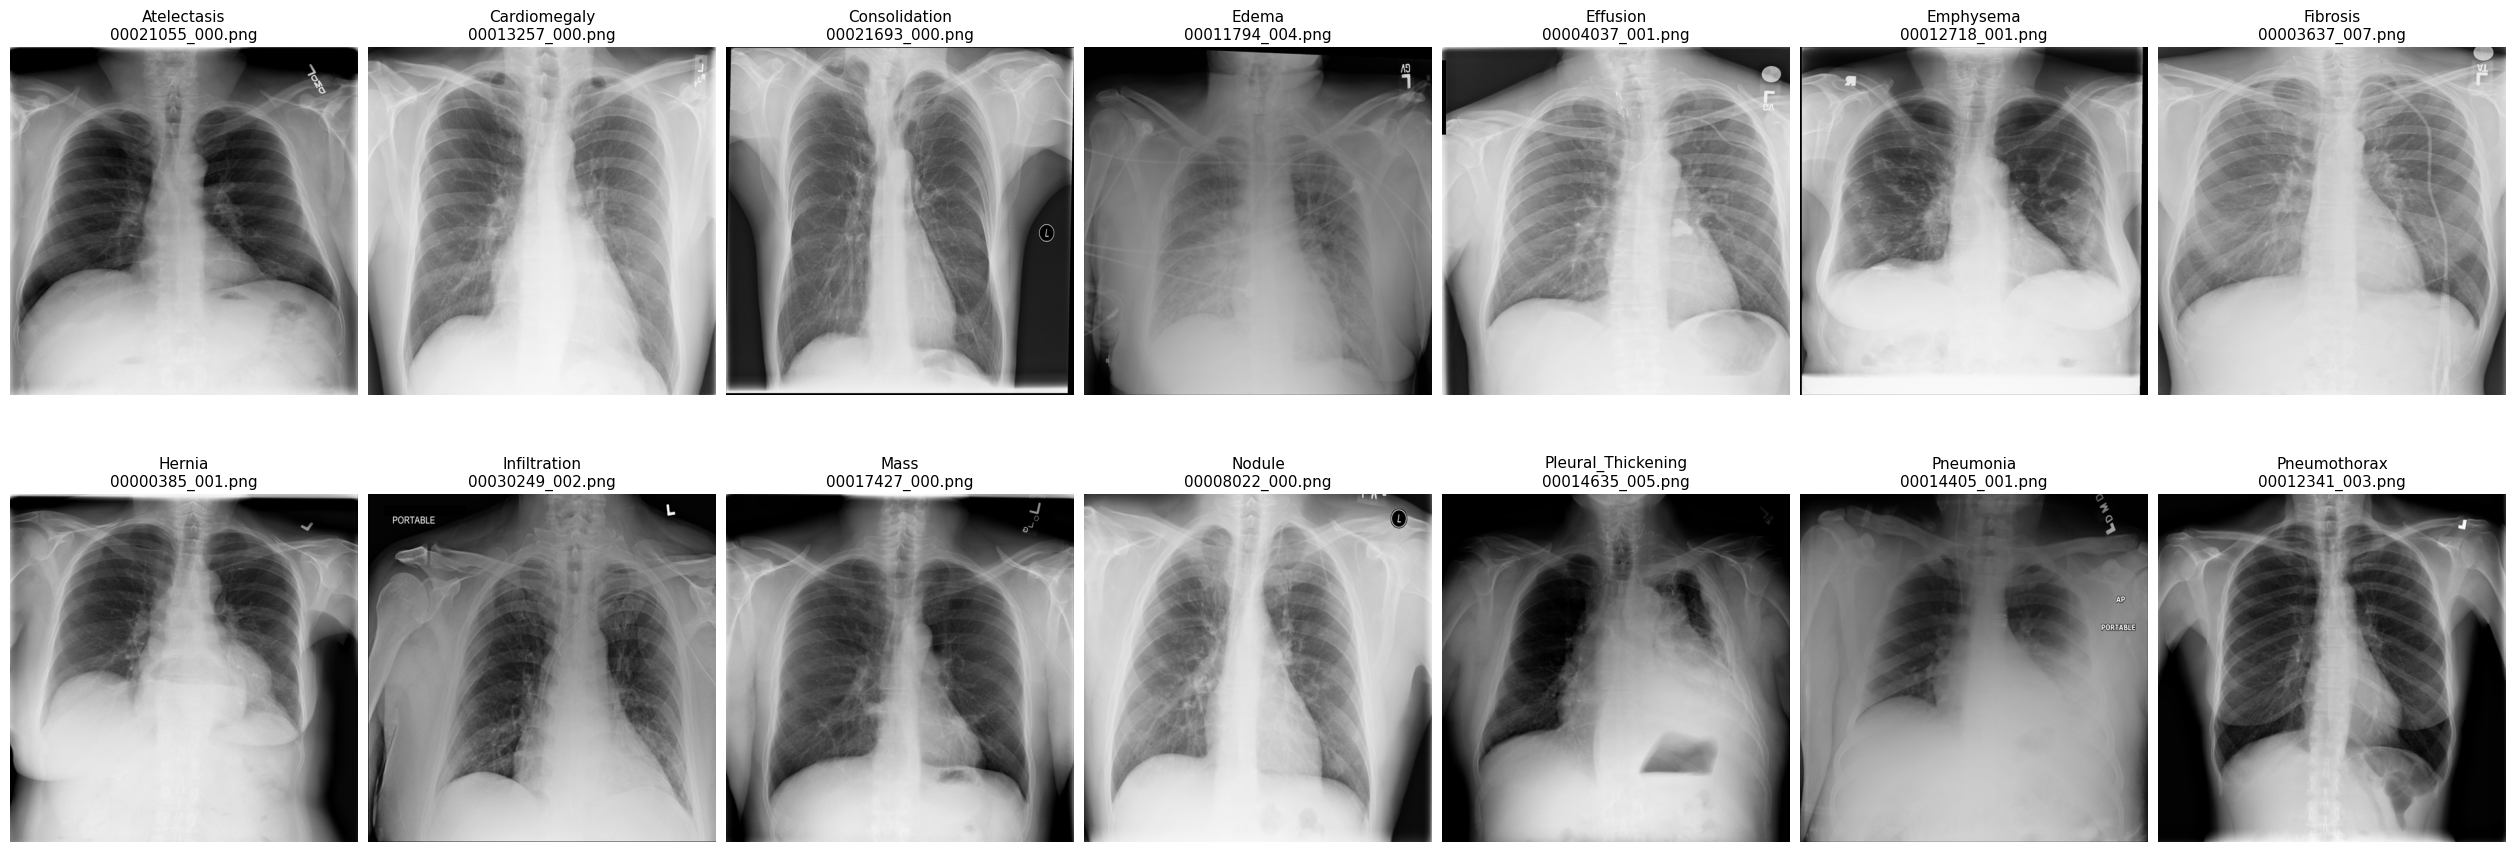

Displayed images: 14
Classes shown: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumonia, Pneumothorax


In [ ]:
# Random 14 images with their linked classes (simple + standalone fallback)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

if "df_one_image_per_patient" in globals():
    sample_df = df_one_image_per_patient.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Data_Entry_2017.csv not found.")

    base_df = pd.read_csv(csv_path)
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column not found.")

    work = base_df[~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")].copy()
    one_label = work[work["Finding Labels"].fillna("").astype(str).str.split("|").str.len().eq(1)].copy()
    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in one_label.columns else [])
    sample_df = one_label.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first").copy()

if "Finding Labels" not in sample_df.columns or "Image Index" not in sample_df.columns:
    raise KeyError("Required columns 'Finding Labels' and 'Image Index' were not found.")

selected = (
    sample_df[sample_df["Finding Labels"].fillna("").astype(str).str.strip().ne("")]
    .sample(frac=1)
    .drop_duplicates(subset="Finding Labels", keep="first")
    .sample(n=min(14, sample_df["Finding Labels"].nunique()))
    .sort_values("Finding Labels")
)

img_dir = next((d for d in [Path("archive") / "images_512", Path("images_512")] if d.exists()), None)
if img_dir is None:
    raise FileNotFoundError("images_512 folder not found. Run the resize cell first.")

selected = selected.copy()
selected["_img_path"] = selected["Image Index"].astype(str).apply(lambda x: img_dir / x)
selected = selected[selected["_img_path"].apply(lambda p: p.exists())].copy()
if selected.empty:
    raise FileNotFoundError("No sampled image files found in images_512.")

fig, axes = plt.subplots(2, 7, figsize=(26, 10), dpi=100)
axes = axes.ravel()
for i, ax in enumerate(axes):
    if i < len(selected):
        row = selected.iloc[i]
        ax.imshow(plt.imread(row["_img_path"]), cmap="gray")
        ax.set_title(f"{row['Finding Labels']}\n{row['Image Index']}", fontsize=11)
    ax.axis("off")

fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.04, wspace=0.03, hspace=0.01)
plt.show()

print(f"Displayed images: {len(selected)}")
print("Classes shown:", ", ".join(selected["Finding Labels"].tolist()))

## Data Splitting:


The cleaned dataset is highly imbalanced, with some disease classes containing many more images than others. A stratified split was used to preserve the class distribution across the training, validation, and test sets. This makes the evaluation more reliable and reduces the risk of rare classes being underrepresented in one of the splits.  


Aso a small subset of 2000 images was used for the first experiment to test the pipeline and verify that preprocessing, label mapping, training, and evaluation worked correctly.  
This subset was not intended for final performance conclusions. After validating the workflow, the model can be scaled to the full cleaned dataset for the actual experiment.

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

if "df_one_image_per_patient" in globals():
    split_source_df = df_one_image_per_patient.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Could not find Data_Entry_2017.csv")

    base_df = pd.read_csv(csv_path)
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column was not found in the dataframe.")

    disease_df = base_df.loc[
        ~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")
    ].copy()
    label_count = disease_df["Finding Labels"].fillna("").astype(str).str.split("|").str.len()
    single_label_df = disease_df.loc[label_count == 1].copy()

    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in single_label_df.columns else [])
    split_source_df = single_label_df.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first").copy()

required_cols = ["Finding Labels", "Image Index"]
missing_cols = [c for c in required_cols if c not in split_source_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for split: {missing_cols}")

work_df = split_source_df.copy()
work_df["Finding Labels"] = work_df["Finding Labels"].fillna("").astype(str).str.strip()
work_df = work_df.loc[work_df["Finding Labels"].ne("")].copy()

class_counts = work_df["Finding Labels"].value_counts()
rare_classes = class_counts[class_counts < 3]
if not rare_classes.empty:
    raise ValueError(
        "Stratified split needs >=3 samples per class for train/val/test. "
        f"Classes with <3 samples: {rare_classes.to_dict()}"
    )

# Use the full cleaned dataset (no pilot sub-sampling).
sample_df = work_df.sample(frac=1.0, random_state=RANDOM_STATE).copy()

train_df, temp_df = train_test_split(
    sample_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=sample_df["Finding Labels"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=temp_df["Finding Labels"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Sample size used: {len(sample_df)}")
print(f"Train size: {len(train_df)} ({len(train_df)/len(sample_df):.2%})")
print(f"Val size:   {len(val_df)} ({len(val_df)/len(sample_df):.2%})")
print(f"Test size:  {len(test_df)} ({len(test_df)/len(sample_df):.2%})")

summary_df = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "pct": [
            len(train_df) / len(sample_df),
            len(val_df) / len(sample_df),
            len(test_df) / len(sample_df),
        ],
    }
)
display(summary_df)

overall_dist = sample_df["Finding Labels"].value_counts(normalize=True).sort_index()
train_dist = train_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
val_dist = val_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
test_dist = test_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)

dist_check = pd.DataFrame(
    {
        "overall": overall_dist,
        "train": train_dist,
        "val": val_dist,
        "test": test_dist,
    }
).round(4)

display(dist_check)

Sample size used: 12252
Train size: 9189 (75.00%)
Val size:   1837 (14.99%)
Test size:  1226 (10.01%)


,split,rows,pct
0,train,9189,0.750000
1,val,1837,0.149935
2,test,1226,0.100065


,overall,train,val,test
Finding Labels,,,,
Atelectasis,0.1419,0.1418,0.1421,0.1419
Cardiomegaly,0.0499,0.0498,0.0501,0.0498
Consolidation,0.0255,0.0255,0.0256,0.0253
Edema,0.0110,0.0110,0.0109,0.0114
Effusion,0.0811,0.0812,0.0811,0.0808
Emphysema,0.0286,0.0286,0.0283,0.0285
Fibrosis,0.0346,0.0346,0.0348,0.0343
Hernia,0.0050,0.0050,0.0049,0.0049
Infiltration,0.3438,0.3438,0.3435,0.3442


--------------------------------

# Training 

In [ ]:
from pathlib import Path
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision
from torchvision import transforms
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy

L.seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if "train_df" not in globals() or "val_df" not in globals() or "test_df" not in globals():
    raise RuntimeError("train_df/val_df/test_df not found. Run the Data Splitting cell first.")

def discover_image_lookup() -> dict:
    roots = []
    candidates = [Path("archive") / "images_512", Path("images_512")]
    for p in candidates:
        if p.exists():
            roots.append(p)

    # Fallback to original NIH folders if resized folder is missing/incomplete.
    for base in [Path("."), Path("archive")]:
        roots.extend(sorted(base.glob("images_*/images")))

    lookup = {}
    for root in roots:
        for img_path in root.glob("*.png"):
            lookup.setdefault(img_path.name, img_path)
    return lookup

image_lookup = discover_image_lookup()
if not image_lookup:
    raise FileNotFoundError("No image files found in images_512 or images_*/images folders.")

label_col = "Finding Labels"
image_col = "Image Index"

for col in [label_col, image_col]:
    if col not in train_df.columns:
        raise KeyError(f"Column '{col}' is missing from train_df.")

all_labels = sorted(train_df[label_col].astype(str).str.strip().unique().tolist())
label_to_idx = {label: i for i, label in enumerate(all_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
num_classes = len(all_labels)

print(f"Number of classes: {num_classes}")

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df[label_col] = split_df[label_col].astype(str).str.strip()
    split_df["_image_path"] = split_df[image_col].astype(str).map(image_lookup)
    before_rows = len(split_df)
    split_df.dropna(subset=["_image_path"], inplace=True)
    dropped = before_rows - len(split_df)
    if dropped > 0:
        print(f"{split_name}: dropped {dropped} rows because image file was missing.")

class XraySingleLabelDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["_image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        target = label_to_idx[row[label_col]]
        return image, target

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = XraySingleLabelDataset(train_df, transform=train_tfms)
val_ds = XraySingleLabelDataset(val_df, transform=val_test_tfms)
test_ds = XraySingleLabelDataset(test_df, transform=val_test_tfms)

batch_size = 32
num_workers = 0

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

class XrayClassifier(L.LightningModule):
    def __init__(self, n_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.backbone = torchvision.models.resnet18(weights="DEFAULT")
        in_features = self.backbone.fc.in_features
        self.backbone.fc = torch.nn.Linear(in_features, n_classes)
        self.criterion = torch.nn.CrossEntropyLoss()
        self.train_acc = MulticlassAccuracy(num_classes=n_classes)
        self.val_acc = MulticlassAccuracy(num_classes=n_classes)

    def forward(self, x):
        return self.backbone(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

model = XrayClassifier(n_classes=num_classes, lr=1e-3)

logger = CSVLogger(save_dir="archive", name="xray_training_logs")
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=3)

trainer = L.Trainer(
    max_epochs=8,
    accelerator="auto",
    devices=1,
    logger=logger,
    callbacks=[early_stop],
    enable_checkpointing=True,
    log_every_n_steps=5,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f"Training complete. Logs: {trainer.logger.log_dir}")

Seed set to 42


Using device: cuda


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Number of classes: 14
Train batches: 288 | Val batches: 58 | Test batches: 39


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_c
onnector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the
value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_c
onnector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=8` reached.


Training complete. Logs: archive\xray_training_logs\version_5


# validation chart 

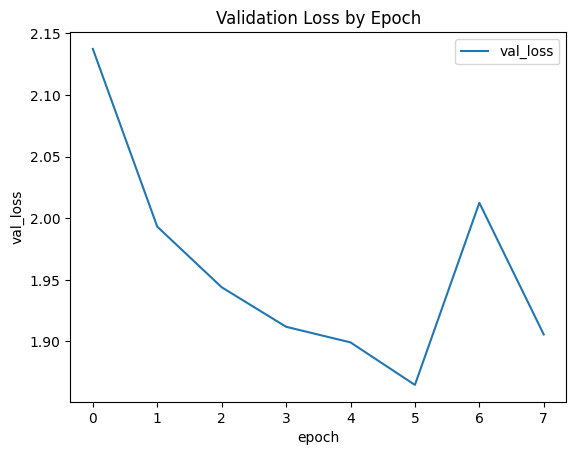

In [ ]:
import os
import pandas as pd

if "trainer" not in globals() or getattr(trainer, "logger", None) is None:
    raise RuntimeError("Trainer/logs not found. Run the Training cell first.")

metrics = pd.read_csv(os.path.join(trainer.logger.log_dir, "metrics.csv"))
loss_metrics = metrics[["epoch", "val_loss"]].dropna(subset=["val_loss"]).set_index("epoch")
plot = loss_metrics.plot(title="Validation Loss by Epoch", ylabel="val_loss")

# Overall Metrics

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

if "model" not in globals() or "test_loader" not in globals():
    raise RuntimeError("Model or test_loader not found. Run the Training cell first.")

eval_device = next(model.parameters()).device
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(eval_device)
        targets = targets.to(eval_device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

correct = (all_preds == all_targets).sum()
total = len(all_targets)
test_accuracy = correct / total if total > 0 else 0.0

print(f"Test samples: {total}")
print(f"Correct predictions: {correct}")
print(f"Overall Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print("\n" + "="*80)
print("Per-Class Precision, Recall, and F1-Score:")
print("="*80)

if "idx_to_label" in globals():
    class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
else:
    class_names = None

print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

Test samples: 1226
Correct predictions: 514
Overall Accuracy: 0.4192 (41.92%)

Per-Class Precision, Recall, and F1-Score:
                    precision    recall  f1-score   support

       Atelectasis     0.4563    0.2701    0.3394       174
      Cardiomegaly     0.4857    0.2787    0.3542        61
     Consolidation     0.0000    0.0000    0.0000        31
             Edema     0.1667    0.0714    0.1000        14
          Effusion     0.4314    0.4444    0.4378        99
         Emphysema     0.0000    0.0000    0.0000        35
          Fibrosis     0.2000    0.0238    0.0426        42
            Hernia     0.0000    0.0000    0.0000         6
      Infiltration     0.4604    0.8128    0.5878       422
              Mass     0.4286    0.1895    0.2628        95
            Nodule     0.2320    0.3111    0.2658       135
Pleural_Thickening     0.0000    0.0000    0.0000        54
         Pneumonia     0.0000    0.0000    0.0000        14
      Pneumothorax     0.1429    0.02

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag